# STABILITY ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import tellurium as te
import matplotlib.pyplot as plt

# Helpers

In [2]:
def runModel(model: str):
    rr = te.loada(model)
    data = rr.simulate(0, 20, 200)
    if True:
        rr.plot(xlabel="time", ylabel="concentration")
        print(rr.getFullJacobian())
        print(rr.getFullEigenValues())
    else:
        linewidth = 5
        plt.plot(data[:,0], data[:, 1], linewidth=linewidth)
        plt.plot(data[:,0], data[:, 2], linewidth=linewidth)
        ax = plt.gca()
        ax.set_xticks([])
        ax.set_yticks([])

# Positive stability margin

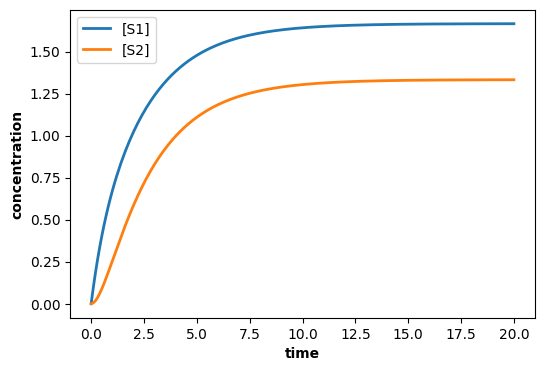

      S1,    S2
S1 [[ -1,   0.5],
S2  [  1, -1.25]]

[-0.40692967+0.j -1.84307033+0.j]


In [3]:
POS_STABILITY_MDL = """
-> S1; 1
S1 -> S2; S1
S2 -> S1; 0.5*S2
S2 -> ; 0.75*S2
"""
runModel(POS_STABILITY_MDL)

# Positive instability margin

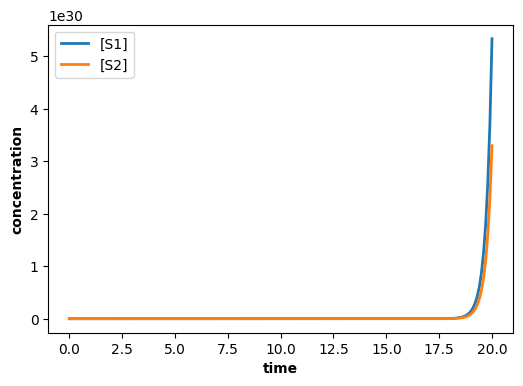

      S1, S2
S1 [[  3,  1],
S2  [  1,  2]]

[3.61803399+0.j 1.38196601+0.j]


In [4]:
POS_INSTABILITY_MDL = """
-> S1; 1
S1 -> 4 S1 + S2; S1
S2 ->  S1 + 3 S2; S2
"""
runModel(POS_INSTABILITY_MDL)

# Negative margins, unstable

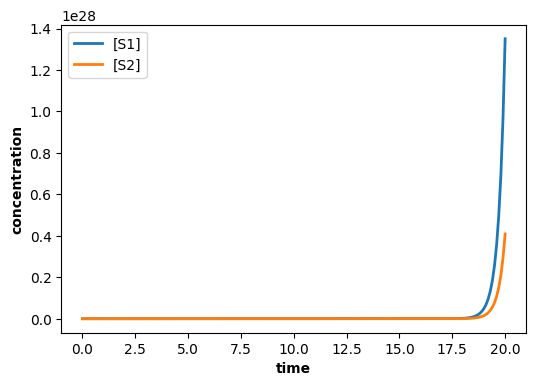

      S1, S2
S1 [[  3,  1],
S2  [  1,  0]]

[ 3.30277564+0.j -0.30277564+0.j]


In [5]:
NEG_MARGINS_UNSTABLE_MDL = """
-> S1; 1
S1 -> 4 S1 + S2; S1
S2 ->  S1 + S2; S2
"""
runModel(NEG_MARGINS_UNSTABLE_MDL)

# Negative margins, stable

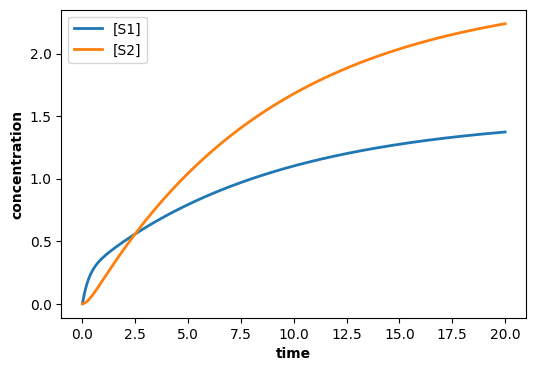

      S1,   S2
S1 [[ -3,  1.4],
S2  [  1, -0.6]]

[-3.48522995+0.j -0.11477005+0.j]


In [6]:
NEG_MARGINS_STABLE_MDL = """
-> S1; 1
S1 ->  S1 + S2; S1
S1 -> ; 3*S1
S2 ->  S1 + 2 S2; 1.4*S2
S2 -> ; 2*S2
"""
runModel(NEG_MARGINS_STABLE_MDL)